# Earthquake events

The USGS Earthquake Hazards Program serves the ANSS Comprehensive Catalog
(ComCat), the combined earthquake catalog of the U.S. seismic networks,
through the FDSN event web service. A query names a time window and
optionally a box and magnitude or depth bounds, and the answer is one CSV of
fixed columns with one row per event: origin time, epicenter, depth,
magnitude, and review status. A response holds at most 20,000 events, so a
larger selection arrives as several pages.

This walkthrough pulls every magnitude 3.0 or larger earthquake in
Oklahoma's bounding box from 2000 to 2024 and counts them by year. It needs
`usdata[pandas]` and matplotlib; the CSV is under 1 MB and the run takes a
few seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T06:02:42+00:00
usdata 0.26.0; pandas 3.0.6


## Select

The service filters on its side, so the manifest's query is the answer.
`location: Oklahoma` becomes the state's bounding box, which takes in strips
of Kansas, Texas, and Arkansas. Bare dates are whole UTC days, so the window
runs from the first instant of 2000 to the last of 2024. `min_magnitude: 3.0`
applies to each event's own magnitude, whatever scale that is. Smaller events
are left out because Oklahoma's seismic network grew much denser after 2010,
and counting them would mix a change in the earth with a change in detection.
The source is named `quakes` so the code below can ask for it by name.

In [2]:
print(manifest.read_text())

name: oklahoma-earthquakes
sources:
  - name: quakes
    dataset: usgs:earthquakes
    # Oklahoma's bounding box, so the edges of Kansas, Texas, and Arkansas count too.
    location: Oklahoma
    start: 2000-01-01
    end: 2024-12-31
    params:
      min_magnitude: 3.0



## What arrives

Listing first asks the service how many events match, then makes one asset
per page of up to 20,000 events. Three thousand events fit on one page. The
first pull writes `dataset.lock.json` beside the manifest with the page's
checksum.

In [3]:
result = pull(manifest)
pages = result.by_source["quakes"]
print("Pages:", len(pages))
item = pages[0]
print("File:", item.path.name)
print("Bytes:", item.provenance.size)
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)

Pages: 1
File: comcat_20000101_20241231_4116d7f38277d776ec1c.csv
Bytes: 517588
Source: https://earthquake.usgs.gov/fdsnws/event/1/query?starttime=2000-01-01T00%3A00%3A00&endtime=2024-12-31T23%3A59%3A59.999999&minmagnitude=3&minlatitude=33.6158&maxlatitude=37.0022&minlongitude=-103.003&maxlongitude=-94.4307&format=csv&orderby=time-asc&limit=20000&offset=1
Retrieved (UTC): 2026-09-24T06:03:07+00:00
Checksum: sha256:68a410e38b2fec7ac8745f622ac676f2d676f82a06cb0c7d375a1541da1bec70


## Open

The generic CSV reader returns a DataFrame; `parse_dates` makes `time` (the
origin time) and `updated` (the last revision) UTC timestamps. `latitude` and
`longitude` are the epicenter in decimal degrees, `depth` is kilometers below
sea level, and `place` is a phrase such as "5 km NW of Pawnee, Oklahoma".
`mag` is on the scale `magType` names, so magnitudes of different types are
not strictly comparable. `status` is `automatic` until a network reviews the
event.

In [4]:
events = item.open_csv(parse_dates=["time", "updated"])
print(f"{len(events)} events, {events['time'].min():%Y-%m-%d} to {events['time'].max():%Y-%m-%d}")
print("Status:", events["status"].value_counts().to_dict())
print("Magnitude types:", events["magType"].value_counts().to_dict())
print("Located by:", events["locationSource"].value_counts().head(3).to_dict())
print(f"Depth: median {events['depth'].median():.1f} km, maximum {events['depth'].max():.1f} km")
columns = ["time", "place", "mag", "magType", "depth"]
events.nlargest(5, "mag")[columns]

3016 events, 2000-08-07 to 2024-11-29
Status: {'reviewed': 3016}
Magnitude types: {'ml': 2312, 'mwr': 495, 'mb_lg': 98, 'mblg': 81, 'md': 15, 'mww': 9, 'mb': 5, 'mwc': 1}
Located by: {'tul': 2661, 'ok': 189, 'us': 151}
Depth: median 5.5 km, maximum 28.6 km


,time,place,mag,magType,depth
2240,2016-09-03 12:02:44.400000+00:00,"14 km NW of Pawnee, Oklahoma",5.80,mww,5.557
105,2011-11-06 03:53:10+00:00,"8 km NW of Prague, Oklahoma",5.70,mww,5.200
1897,2016-02-13 17:07:06.290000+00:00,"18 km SE of Waynoka, Oklahoma",5.10,mww,8.310
2996,2024-02-03 05:24:28.269000+00:00,"8 km NW of Prague, Oklahoma",5.06,mww,3.000
2348,2016-11-07 01:44:24.500000+00:00,"3 km W of Cushing, Oklahoma",5.00,mww,4.430


Almost every event here is shallow, a few kilometers down. Most were located
by the Oklahoma Geological Survey (`locationSource` `tul` or `ok`) and carry
its local magnitude `ml`; many of the larger ones carry a moment magnitude
(`mwr`, `mww`) instead.

## A first look

Magnitude 3 and larger earthquakes per year.

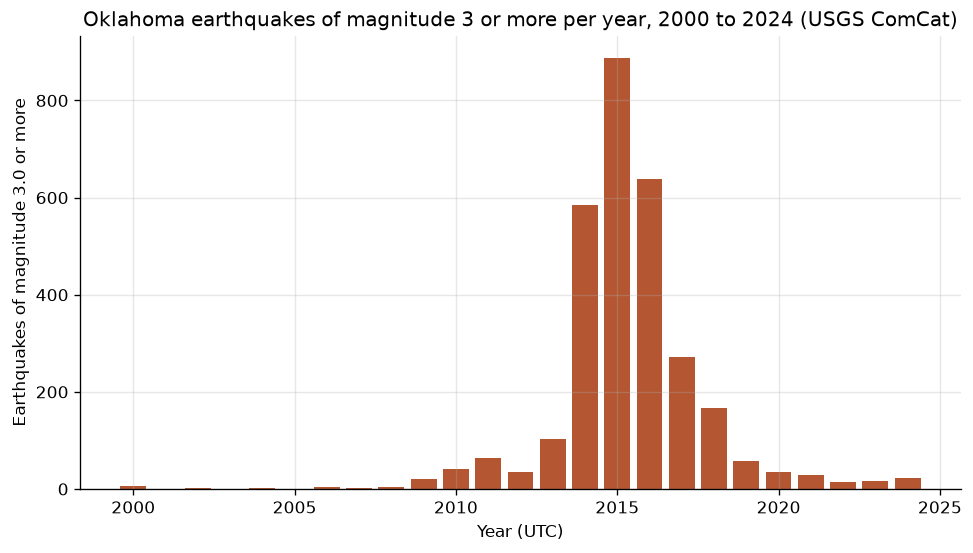

In [5]:
per_year = events.groupby(events["time"].dt.year).size().reindex(range(2000, 2025), fill_value=0)
fig, ax = plt.subplots(layout="constrained")
ax.bar(per_year.index, per_year.values, color="#b45631")
ax.set_xlabel("Year (UTC)")
ax.set_ylabel("Earthquakes of magnitude 3.0 or more")
ax.set_title("Oklahoma earthquakes of magnitude 3 or more per year, 2000 to 2024 (USGS ComCat)")
plt.show()

In [6]:
early = per_year.loc[2000:2008]
print(f"2000 to 2008: {early.sum()} events in nine years")
print(f"Peak: {per_year.idxmax()} with {per_year.max()}")
surge = per_year.loc[2014:2016].sum()
print(f"2014 to 2016: {surge} events ({surge / per_year.sum():.0%} of the total)")
print(f"2024: {per_year[2024]}")
strongest = events.loc[events["mag"].idxmax()]
when = f"{strongest['time']:%Y-%m-%d}"
print(f"Largest: M{strongest['mag']} ({strongest['magType']}) on {when}, {strongest['place']}")

2000 to 2008: 25 events in nine years
Peak: 2015 with 888
2014 to 2016: 2112 events (70% of the total)
2024: 23
Largest: M5.8 (mww) on 2016-09-03, 14 km NW of Pawnee, Oklahoma


Oklahoma went from 25 magnitude 3 earthquakes in nine years (2000 to 2008) to
888 in 2015 alone; 2014 to 2016 hold 70% of the quarter century's events,
including the largest, magnitude 5.8 near Pawnee in September 2016. By 2020
the rate was back to a few dozen a year. The USGS and the
Oklahoma Geological Survey attribute the surge to the disposal of oil and gas
wastewater in deep wells; the decline followed state orders from 2015 to cut
injection volumes. The catalog shows the timing; it does not by itself show
the cause.

## Pin and cite

`verify` checks the cached page against the lockfile's checksum. Keep the
manifest and lockfile with your analysis; the citation below is what a
methods section needs, and `usdata cite dataset.yaml` prints the same.

In [7]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

usgs:earthquakes
  U.S. Geological Survey, Earthquake Hazards Program, 2017, Advanced National Seismic System (ANSS) Comprehensive Catalog of Earthquake Events and Products, doi:10.5066/F7MS3QZH
  homepage: https://earthquake.usgs.gov/fdsnws/event/1/
  license: US Government Work (public domain)
  terms: https://www.usgs.gov/information-policies-and-instructions/copyrights-and-credits
  retrieved: 2026-09-24; 1 checksummed asset (517,588 bytes) pinned by usdata 0.26.0
  sources: quakes


## What was awkward

- A place name is a bounding box, not a boundary. Oklahoma's box includes
  events in Kansas and the Texas Panhandle; filter on coordinates or `place`
  for the state alone.
- `place` is free text for people, not a field for code: most rows end in
  "Oklahoma", some in "OK", and older ones name a region such as "Texas
  Panhandle region".
- `magType` mixes scales, and spells one of them two ways (`mb_lg` and
  `mblg`). Filtering or averaging on `mag` treats them as one scale.
- The catalog is revised as networks review events, so `updated` moves and a
  later pull of the same window can report drift; `usdata pull --update`
  accepts the revised page. With 25 years in one page, one revised event
  anywhere in them changes the page's checksum.
- A window with no events fails with `EmptySource` unless the source sets
  `allow_empty: true`. That is correct, but the first run of a quiet window
  reads like a broken query rather than an empty answer. The
  [earthquake guide](https://docs.usdata.dev/providers/usgs-earthquakes/)
  covers paging, bounds, and revisions.